<a href="https://colab.research.google.com/github/hfzizzulhaq24/study_caseDA/blob/main/Study_Case_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Understanding

Data ini adalah data transaksi booking pelanggan hotel selama 3 tahun yaitu tahun 2017 - 2019 dengan terdapat kolom seperti yang tertera dibawah ini

| Kolom         | Penjelasan                                                          | Jenis Data   |
| ------------- | ------------------------------------------------------------------- | ----------------- |
| `is_canceled` | Apakah pemesanan dibatalkan atau tidak (1 = dibatalkan, 0 = tidak). | Binary (int) |
| `lead_time`                 | Jumlah hari antara tanggal pemesanan dan tanggal kedatangan. | Numeric (int)        |
| `arrival_date_year`         | Tahun kedatangan tamu.                                       | Numeric (int)        |
| `arrival_date_month`        | Bulan kedatangan tamu.                                       | Categorical (object) |
| `arrival_date_week_number`  | Nomor minggu dari tahun kedatangan.                          | Numeric (int)        |
| `arrival_date_day_of_month` | Tanggal kedatangan dalam satu bulan.                         | Numeric (int)  |      
| `stays_in_weekend_nights` | Jumlah malam akhir pekan (sabtu/minggu) yang dipesan. | Numeric (int) |
| `stays_in_week_nights`    | Jumlah malam hari kerja yang dipesan.                 | Numeric (int) |
| `adults`   | Jumlah tamu dewasa. | Numeric (int)                                  |
| `children` | Jumlah anak-anak.   | Numeric (float, karena bisa ada nilai kosong). |
| `babies`   | Jumlah bayi.        | Numeric (float).                               |
| `meal`                           | Jenis paket makanan (misal: Breakfast Only, Full Board).          | Categorical  |
| `country`                        | Negara asal tamu.                                                 | Categorical  |
| `market_segment`                 | Sumber pemesanan (misal: Online TA, Corporate, Direct).           | Categorical  |
| `distribution_channel`           | Jalur distribusi (misal: GDS, TA, Corporate).                     | Categorical  |
| `is_repeated_guest`              | Apakah tamu sudah pernah menginap sebelumnya (1 = ya, 0 = tidak). | Binary (int) |
| `previous_cancellations`         | Jumlah pembatalan pemesanan sebelumnya oleh tamu.                 | Numeric      |
| `previous_bookings_not_canceled` | Jumlah pemesanan sebelumnya yang tidak dibatalkan.                | Numeric      |
| `reserved_room_type` | Jenis kamar yang awalnya dipesan.                                    | Categorical |
| `assigned_room_type` | Jenis kamar yang akhirnya diberikan.                                 | Categorical |
| `booking_changes`    | Jumlah perubahan pada pemesanan.                                     | Numeric     |
| `deposit_type`       | Jenis deposit yang dilakukan (No Deposit / Non Refund / Refundable). | Categorical |
| `agent`              | ID agen pemesanan (jika ada).                                        | Numeric     |
| `company`            | ID perusahaan pemesan (jika ada).                                    | Numeric     |
| `days_in_waiting_list`        | Lama waktu pemesanan berada di daftar tunggu.                              | Numeric              |
| `customer_type`               | Jenis pelanggan (misal: Transient, Group, Contract).                       | Categorical          |
| `adr`                         | Average Daily Rate — pendapatan per malam dari kamar yang dipesan.         | Numeric (float)      |
| `required_car_parking_spaces` | Jumlah tempat parkir yang diminta.                                         | Numeric              |
| `total_of_special_requests`   | Jumlah permintaan khusus (misal: tempat tidur tambahan, pemandangan laut). | Numeric              |
| `reservation_status`          | Status akhir reservasi (Checked-Out, Canceled, No-Show).                   | Categorical          |
| `reservation_status_date`     | Tanggal ketika status terakhir ditetapkan.                                 | DateTime atau Object |


# import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
sns.set(style="whitegrid")

# Read Data

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

# Data Preprocessing

## Descrptive

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,83293.0,0.369503,0.482673,0.0,0.00,0.0,1.0,1.0
lead_time,83293.0,103.914230,106.874124,0.0,18.00,69.0,160.0,737.0
arrival_date_year,83293.0,2018.156808,0.706656,2017.0,2018.00,2018.0,2019.0,2019.0
arrival_date_week_number,83293.0,27.164023,13.623752,1.0,16.00,27.0,38.0,53.0
arrival_date_day_of_month,83293.0,15.786116,8.775931,1.0,8.00,16.0,23.0,31.0
stays_in_weekend_nights,83293.0,0.930390,1.004196,0.0,0.00,1.0,2.0,19.0
stays_in_week_nights,83293.0,2.503812,1.924511,0.0,1.00,2.0,3.0,50.0
adults,83293.0,1.854466,0.606139,0.0,2.00,2.0,2.0,55.0
children,83290.0,0.103614,0.398821,0.0,0.00,0.0,0.0,10.0
babies,83293.0,0.008032,0.100641,0.0,0.00,0.0,0.0,10.0


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
hotel,83293,64,Renaissance New York Times Square Hotel New Yo...,1373
arrival_date_month,83293,12,August,9643
meal,83293,5,BB,64424
country,82947,165,PRT,33952
market_segment,83293,8,Online TA,39445
distribution_channel,83293,5,TA/TO,68368
reserved_room_type,83293,10,A,60062
assigned_room_type,83293,11,A,51702
deposit_type,83293,3,No Deposit,72979
customer_type,83293,4,Transient,62535


In [ ]:
df['country'].value_counts()

,count
country,
PRT,33952
GBR,8381
FRA,7243
ESP,5897
DEU,5107
...,...
MWI,1
SLE,1
MDG,1


Berdasarkan data di atas, terdapat sekitar 33.952 data pemesanan yang berasal dari negara Portugal (PRT). Oleh karena itu, pada analisis ini saya akan memfokuskan pembahasan hanya pada data pelanggan dari Portugal.

In [ ]:
df_prt = df[df['country'] == 'PRT']

print(f"Jumlah data untuk negara PRT: {len(df_prt)} baris")
df_prt.sample(5)

Jumlah data untuk negara PRT: 33952 baris


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
74964,Courtyard by Marriott Paris Gare de Lyon Paris...,0,175,2019,June,23,9,0,2,2,...,3.0,NaN,0,Transient-Party,130.00,0,0,Check-Out,2019-06-11,74965
66311,"Frankfurt Marriott Hotel Frankfurt, Germany",1,205,2018,September,38,16,1,2,2,...,37.0,NaN,0,Transient,120.00,0,0,Canceled,2018-03-15,66312
82522,"Tamarind, Barbados Barbados",1,181,2018,October,43,16,2,1,2,...,11.0,NaN,0,Transient,37.00,0,0,Canceled,2018-07-18,82523
65113,"Sheraton Lima Hotel & Convention Center Lima, ...",0,19,2017,July,30,25,2,2,2,...,1.0,NaN,0,Transient-Party,62.00,0,0,Check-Out,2017-07-29,65114
36098,Orlando International Drive/Convention Center ...,0,12,2018,April,18,27,0,3,2,...,385.0,NaN,0,Transient-Party,85.33,0,0,Check-Out,2018-04-30,36099


## Alter Data

In [ ]:
df_prt['reservation_status_date'] = pd.to_datetime(df_prt['reservation_status_date'])
df_prt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33952 entries, 1 to 83285
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           33952 non-null  object        
 1   is_canceled                     33952 non-null  int64         
 2   lead_time                       33952 non-null  int64         
 3   arrival_date_year               33952 non-null  int64         
 4   arrival_date_month              33952 non-null  object        
 5   arrival_date_week_number        33952 non-null  int64         
 6   arrival_date_day_of_month       33952 non-null  int64         
 7   stays_in_weekend_nights         33952 non-null  int64         
 8   stays_in_week_nights            33952 non-null  int64         
 9   adults                          33952 non-null  int64         
 10  children                        33949 non-null  float64       
 11  babies 

/tmp/ipython-input-3231486005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prt['reservation_status_date'] = pd.to_datetime(df_prt['reservation_status_date'])


Melakukan konversi data reservation status date ke data time

## Handling Missing Values

In [ ]:
df_prt.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Ditemukan missing values pada beberapa kolom berikut:

* Children: 3 data hilang
* Agent: 7.708 data hilang
* Company: 30.797 data hilang

Kolom Company dan Agent memiliki jumlah data hilang yang cukup besar, mendekati sebagian besar total data. Karena kolom Company hanya berisi ID perusahaan yang tidak relevan dengan analisis utama, maka kolom ini dihapus.

In [ ]:
## drop kolom yang tidak terpakai
df_prt = df_prt.drop(['agent','company'], axis=1)

In [ ]:
# Handling Missing Values
for column in df_prt.select_dtypes(include=[np.number]).columns:
  df_prt[column].fillna(df_prt[column].mean(), inplace=True)

for column in df_prt.select_dtypes(include=[object]).columns:
  df_prt[column].fillna(df_prt[column].mode()[0], inplace=True)

df_prt.isnull().sum()

/tmp/ipython-input-1270020846.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_prt[column].fillna(df_prt[column].mean(), inplace=True)
/tmp/ipython-input-1270020846.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Sudah tidak terdapat missing values

## Handling duplicate

In [ ]:
print('Duplicate values is ', df_prt.duplicated().sum())

Duplicate values is  0


## Check Values

In [ ]:
for col in df_prt.columns:
    print(f"\n{'-'*30} {col} {'-'*30}")
    print(df_prt[col].value_counts())


------------------------------ hotel ------------------------------
hotel
Renaissance New York Times Square Hotel New York, NY                      576
Hotel Maria Cristina, San Sebastian San Sebastian, Spain                  575
The Ritz-Carlton, Tokyo Tokyo, Japan                                      575
Protea Hotel by Marriott Midrand Midrand, South Africa                    568
Heidelberg Marriott Hotel Heidelberg, Germany                             566
                                                                         ... 
The House, Barbados Barbados                                              503
Protea Hotel by Marriott O.R. Tambo Airport Johannesburg, South Africa    502
Fort Worth University Drive Courtyard Fort Worth, TX                      501
Leipzig Marriott Hotel Leipzig, Germany                                   497
Residence Inn Rio de Janeiro Barra da Tijuca Barra da Tijuca, Brazil      490
Name: count, Length: 64, dtype: int64

----------------------------

Ditemukan nilai “Undefined” pada tiga kolom kategorikal berikut:

* Meal
* Market Segment
* Distribution Channel

Karena ketiganya merupakan kolom bertipe kategorikal, maka penanganan dilakukan dengan mengganti nilai “Undefined” menggunakan nilai modus pada masing-masing kolom.


In [ ]:
# Mengganti Undefinde Values
kolom_undefined = ['meal', 'market_segment', 'distribution_channel']

for kolom in kolom_undefined:
    mode_value = df_prt[kolom].mode()[0]
    df_prt[kolom] = df_prt[kolom].replace('Undefined', mode_value)
    print(f"Nilai 'Undefined' pada kolom '{kolom}' telah diganti dengan modus: {mode_value}")

for kolom in kolom_undefined:
    print(f"\nDistribusi nilai untuk kolom {kolom}:")
    print(df_prt[kolom].value_counts())

Nilai 'Undefined' pada kolom 'meal' telah diganti dengan modus: BB
Nilai 'Undefined' pada kolom 'market_segment' telah diganti dengan modus: Groups
Nilai 'Undefined' pada kolom 'distribution_channel' telah diganti dengan modus: TA/TO

Distribusi nilai untuk kolom meal:
meal
BB    28105
HB     4317
SC     1103
FB      427
Name: count, dtype: int64

Distribusi nilai untuk kolom market_segment:
market_segment
Groups           9658
Online TA        8427
Offline TA/TO    8381
Direct           4046
Corporate        2893
Complementary     471
Aviation           76
Name: count, dtype: int64

Distribusi nilai untuk kolom distribution_channel:
distribution_channel
TA/TO        25715
Direct        5046
Corporate     3176
GDS             15
Name: count, dtype: int64


Data Siap melakukan Explorasi Data Analysis

In [ ]:
df_clean = df_prt.copy()

# EDA

## Check Cancel Distribution

/tmp/ipython-input-1737933823.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


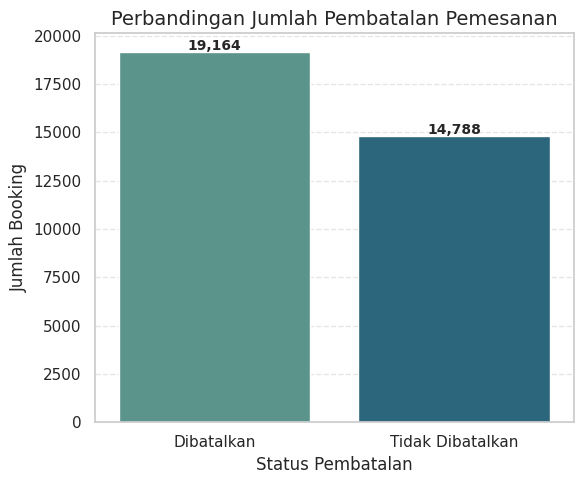

In [ ]:
cancel_counts = df_clean['is_canceled'].value_counts().reset_index()
cancel_counts.columns = ['is_canceled', 'count']

cancel_counts['status'] = cancel_counts['is_canceled'].map({0: 'Tidak Dibatalkan', 1: 'Dibatalkan'})

plt.figure(figsize=(6,5))
sns.barplot(
    data=cancel_counts,
    x='status',
    y='count',
    palette='crest'
)
for index, row in cancel_counts.iterrows():
    plt.text(index, row['count'] + 100, f"{row['count']:,}", ha='center', fontsize=10, weight='bold')

plt.title('Perbandingan Jumlah Pembatalan Pemesanan', fontsize=14)
plt.xlabel('Status Pembatalan')
plt.ylabel('Jumlah Booking')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
cancel_percent = df_clean['is_canceled'].value_counts(normalize=True) * 100
cancel_percent = cancel_percent.rename(index={0: 'Tidak Dibatalkan', 1: 'Dibatalkan'})

print("Persentase Pembatalan Pemesanan:")
print(cancel_percent.round(1))

Persentase Pembatalan Pemesanan:
is_canceled
Dibatalkan          56.4
Tidak Dibatalkan    43.6
Name: proportion, dtype: float64


Berdasarkan hasil visualisasi, jumlah pelanggan yang melakukan pembatalan jauh lebih tinggi dibandingkan yang tidak, dengan total 19.164 pelanggan atau sekitar 56% dari seluruh data. Angka ini cukup signifikan dan berpotensi berdampak besar terhadap pendapatan hotel. Oleh karena itu, pihak manajemen perlu melakukan analisis lebih lanjut untuk mengidentifikasi faktor-faktor yang memengaruhi keputusan pembatalan tersebut.

## Check Correlation Numerik

In [ ]:
num_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'is_canceled'
]

numeric_df = df_clean[num_cols]
corr = numeric_df.corr()

corr_with_cancel = corr['is_canceled'].sort_values(ascending=False)
print(corr_with_cancel)

is_canceled                       1.000000
lead_time                         0.464195
stays_in_week_nights              0.141868
adults                            0.112729
stays_in_weekend_nights           0.102725
previous_cancellations            0.101743
days_in_waiting_list              0.084386
adr                               0.028189
babies                           -0.051584
children                         -0.060103
previous_bookings_not_canceled   -0.129430
booking_changes                  -0.222802
total_of_special_requests        -0.272551
required_car_parking_spaces      -0.294908
Name: is_canceled, dtype: float64


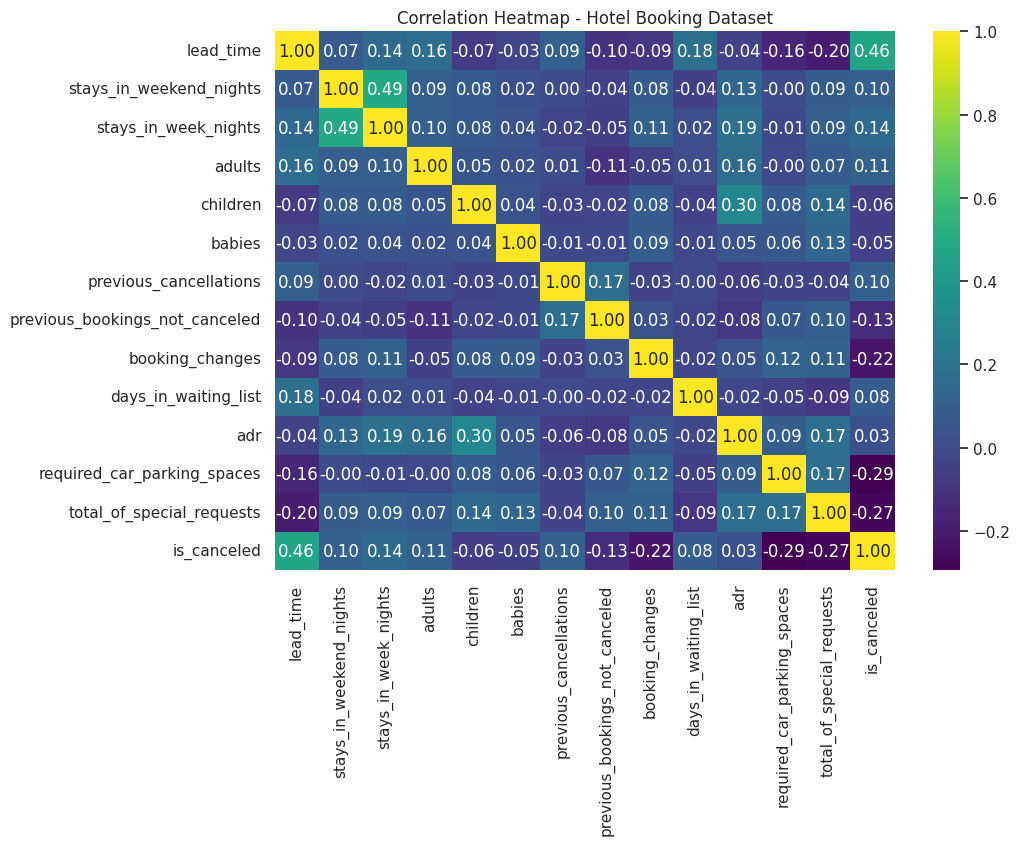

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f")
plt.title("Correlation Heatmap - Hotel Booking Dataset")
plt.show()

Karena dataset ini memiliki cukup banyak fitur numerik, maka dilakukan pemeriksaan multikolinearitas (correlation check) untuk mengetahui fitur mana yang memiliki hubungan paling kuat terhadap variabel pembatalan (is_canceled).

Berdasarkan hasil analisis korelasi, beberapa fitur yang memiliki korelasi paling tinggi terhadap pembatalan adalah:

* Lead Time: 0.46
* Required Car Parking Spaces: 0.29
* Total of Special Requests: 0.27

Nilai-nilai tersebut menunjukkan bahwa semakin tinggi nilai pada fitur-fitur di atas, semakin besar kemungkinan pelanggan melakukan pembatalan.

### Korelasi antara Booking cencel dan Lead Time

/tmp/ipython-input-3265378128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


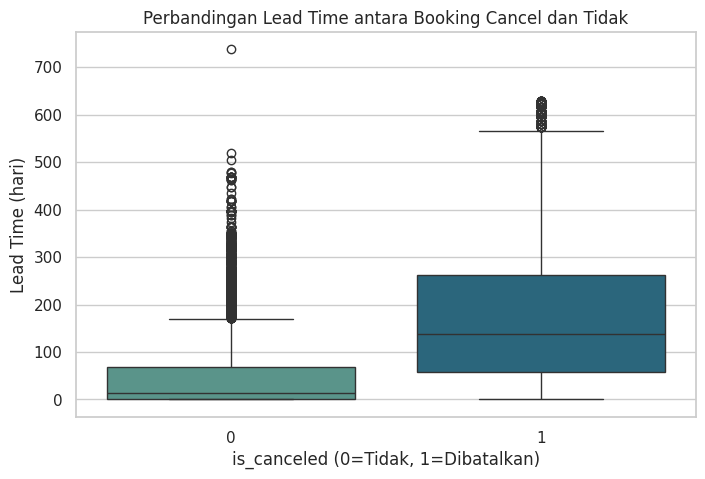

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='is_canceled',
    y='lead_time',
    data=df_clean,
    palette='crest'
)

plt.title('Perbandingan Lead Time antara Booking Cancel dan Tidak')
plt.xlabel('is_canceled (0=Tidak, 1=Dibatalkan)')
plt.ylabel('Lead Time (hari)')
plt.show()

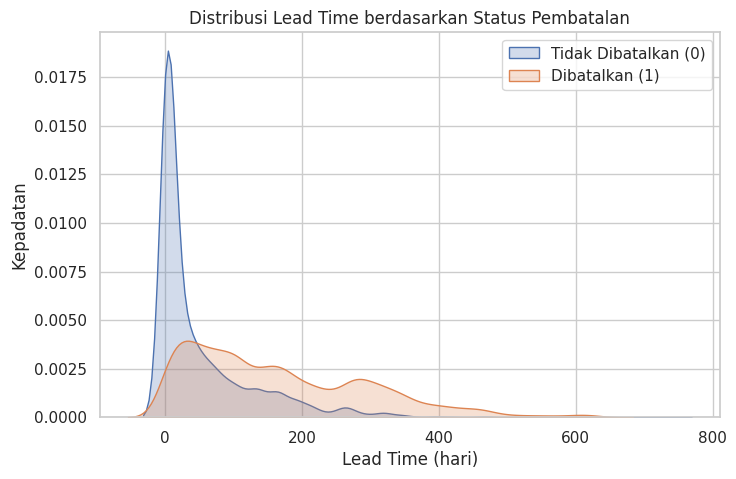

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df_clean.loc[df_clean['is_canceled'] == 0, 'lead_time'], label='Tidak Dibatalkan (0)', fill=True)
sns.kdeplot(df_clean.loc[df_clean['is_canceled'] == 1, 'lead_time'], label='Dibatalkan (1)', fill=True)
plt.title('Distribusi Lead Time berdasarkan Status Pembatalan')
plt.xlabel('Lead Time (hari)')
plt.ylabel('Kepadatan')
plt.legend()
plt.show()

Insight :
* Customer dengan lead time panjang (0–400 hari) memiliki tingkat pembatalan yang lebih tinggi.
* Customer yang tidak melakukan pembatalan umumnya memiliki lead time pendek (0–50 hari).
* Terlihat adanya kecenderungan bahwa semakin lama waktu antara pemesanan dan tanggal menginap, semakin besar kemungkinan pembatalan terjadi.

Asumsi :
* Kemungkinan penyebab utama adalah karena customer yang memesan jauh-jauh hari memiliki lebih banyak waktu untuk mengubah rencana perjalanan, membandingkan harga dengan hotel lain, atau mendapatkan penawaran yang lebih baik, sehingga peluang untuk membatalkan pemesanan menjadi lebih tinggi.

### Korelasi antara Spesial Req dan Booking Cencel

/tmp/ipython-input-3996139877.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=req_cancel, x='total_of_special_requests', y='is_canceled', palette='crest')


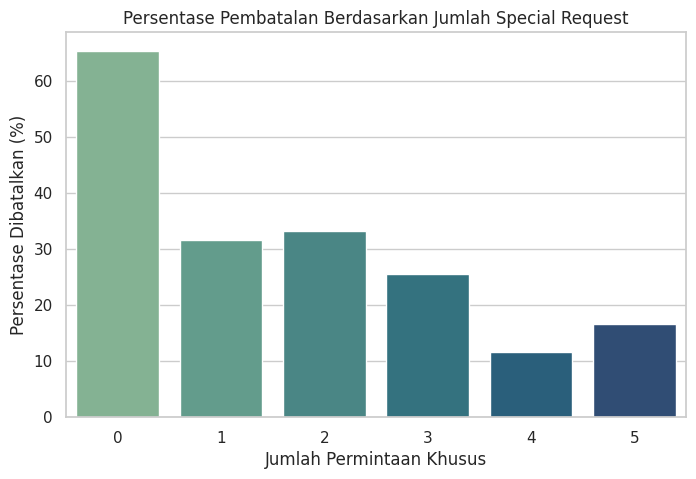

In [ ]:
req_cancel = df_clean.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()
req_cancel['is_canceled'] *= 100  # ubah ke persen

plt.figure(figsize=(8,5))
sns.barplot(data=req_cancel, x='total_of_special_requests', y='is_canceled', palette='crest')
plt.title('Persentase Pembatalan Berdasarkan Jumlah Special Request')
plt.xlabel('Jumlah Permintaan Khusus')
plt.ylabel('Persentase Dibatalkan (%)')
plt.show()

Rata-rata customer yang paling banyak tidak melakukan request sekitar lebih dari 60%, sedangkan customer yang melakukan request memiliki rata-rata pembatalan pemesanan sekitar sekitar 11% - 32%

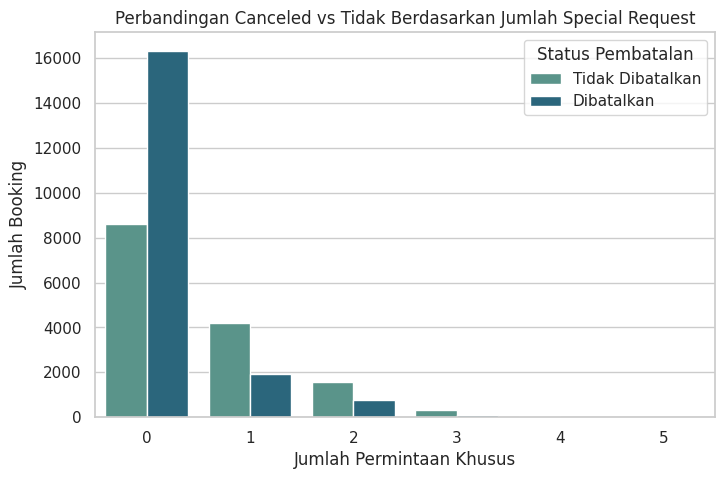

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='total_of_special_requests',
    hue='is_canceled',
    palette='crest'
)

plt.title('Perbandingan Canceled vs Tidak Berdasarkan Jumlah Special Request')
plt.xlabel('Jumlah Permintaan Khusus')
plt.ylabel('Jumlah Booking')
plt.legend(title='Status Pembatalan', labels=['Tidak Dibatalkan', 'Dibatalkan'])
plt.show()

Insight :
* Sebagian besar customer yang membatalkan pemesanan adalah mereka yang tidak memiliki special request, yaitu sekitar 16.000 customer.
* Semakin banyak jumlah permintaan khusus (special request), maka tingkat pembatalan semakin menurun.
* Customer yang memiliki lebih dari satu permintaan khusus cenderung lebih berkomitmen terhadap pesanannya.

Asumsi :
* Customer tanpa special request kemungkinan melakukan pemesanan tanpa perencanaan matang atau tidak terlalu peduli terhadap detail pengalaman menginap, sehingga lebih mudah membatalkan.

### Korelasi Antara Req Parking car dengan cenceled

/tmp/ipython-input-2935260999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='required_car_parking_spaces', palette='crest')


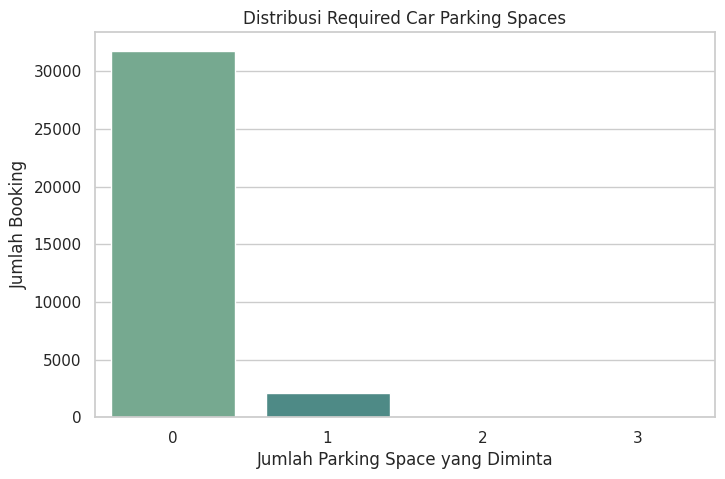

In [ ]:
# Distribusi customer req parking spaces
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='required_car_parking_spaces', palette='crest')
plt.title('Distribusi Required Car Parking Spaces')
plt.xlabel('Jumlah Parking Space yang Diminta')
plt.ylabel('Jumlah Booking')
plt.show()

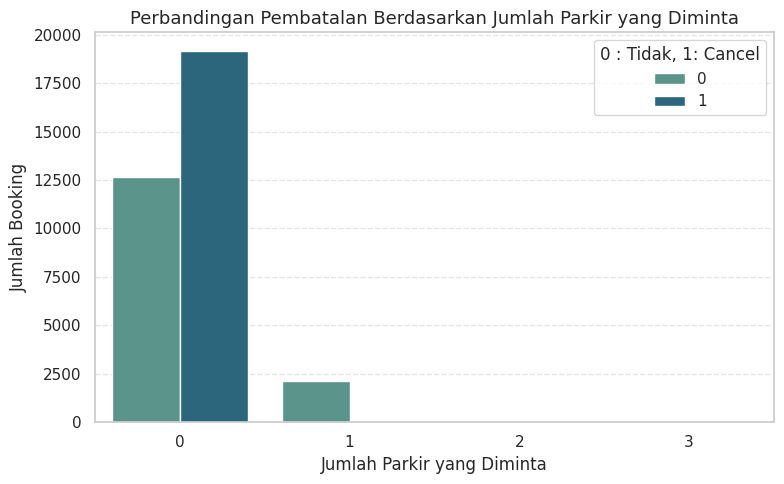

In [ ]:
# Hitung jumlah pelanggan cancel vs tidak cancel per jumlah parkir
parking_cancel = (
    df_clean.groupby(['required_car_parking_spaces', 'is_canceled'])
      .size()
      .reset_index(name='count')
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=parking_cancel,
    x='required_car_parking_spaces',
    y='count',
    hue='is_canceled',
    palette='crest'
)

plt.title('Perbandingan Pembatalan Berdasarkan Jumlah Parkir yang Diminta', fontsize=13)
plt.xlabel('Jumlah Parkir yang Diminta')
plt.ylabel('Jumlah Booking')
plt.legend(title='0 : Tidak, 1: Cancel')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Insight :
* Customer yang tidak meminta tempat parkir (0) memiliki jumlah pembatalan paling tinggi, yaitu sekitar 18.000 pembatalan.
* Sebaliknya, customer yang meminta parkir (1) memiliki tingkat pembatalan yang lebih rendah secara signifikan.

Asumsi :
* Customer yang tidak membutuhkan tempat parkir kemungkinan besar berasal dari luar kota atau menggunakan transportasi umum, sehingga rencana perjalanan mereka lebih mudah berubah dan berpotensi membatalkan pemesanan.
Sedangkan customer yang memesan tempat parkir cenderung sudah memiliki rencana perjalanan yang lebih pasti dan matang, sehingga kemungkinan pembatalan lebih kecil.

## Korelasi Kolom Kategori dengan Kolom Canceled

In [ ]:
from itertools import combinations
# Fungsi Cramér’s V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))

# Buat matriks korelasi antar fitur kategorikal
def categorical_corr_matrix(df):
    cat_cols = df.select_dtypes(include=['object']).columns
    matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

    for col1, col2 in combinations(cat_cols, 2):
        v = cramers_v(df[col1], df[col2])
        matrix.loc[col1, col2] = v
        matrix.loc[col2, col1] = v

    np.fill_diagonal(matrix.values, 1.0)
    return matrix

/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r

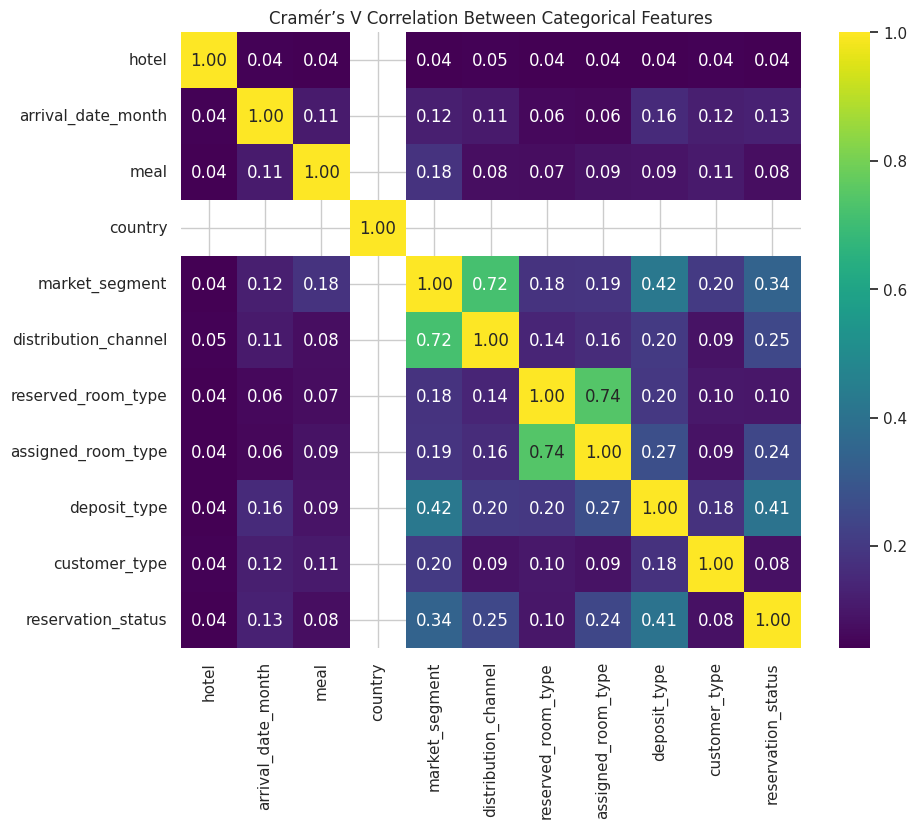

In [ ]:
cat_corr_matrix = categorical_corr_matrix(df_clean)

plt.figure(figsize=(10,8))
sns.heatmap(cat_corr_matrix, annot=True,cmap='viridis', fmt=".2f")
plt.title("Cramér’s V Correlation Between Categorical Features")
plt.show()

Dari hasil korelasi antar feature di atas memiliki nilai yang cukup tinggi sehingga salah satu dari feature dengan nilai korelasi yang tinggi tidak di gunakan, adapun feature dengan nilai korelasi yang cukup tinggi adalaha

*   distribution_channel x market_segment (0.72)
*   assigned_room_type x reserved_room_type (0.74)

dari ke 4 feature di atas akan di pilih satu dengan nilai korelasi antar feature canceled yang tinggi

In [ ]:
def categorical_correlation(df_clean, target_col='is_canceled'):
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    results = []

    for col in cat_cols:
        v = cramers_v(df_clean[col], df_clean[target_col])
        results.append({'Feature': col, 'CramersV': v})

    result_df_clean = pd.DataFrame(results).sort_values(by='CramersV', ascending=False).reset_index(drop=True)
    return result_df_clean

corr_cat = categorical_correlation(df_clean)
print(corr_cat)

                 Feature  CramersV
0     reservation_status  1.000000
1           deposit_type  0.560708
2         market_segment  0.471163
3   distribution_channel  0.345999
4     assigned_room_type  0.338133
5     arrival_date_month  0.162590
6     reserved_room_type  0.136576
7          customer_type  0.116560
8                   meal  0.098401
9                  hotel  0.043359
10               country       NaN


/tmp/ipython-input-21188862.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))


Karna nilai feature market_segment memiliki nilai korelasi yang cukup tinggi dibandingkan distribution channel sehingga untuk korelasi feature dengan kolom canceled di dapatkan :
* Deposit Type (0.56)
* Market Segment (0.47)

Kedua feature kategorikal diatas adalah feature dengan pengaruh tertinggi terhadap customer yang melakukan canceled

### Type Of Deposit

/tmp/ipython-input-4261562306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='deposit_type', palette='crest')


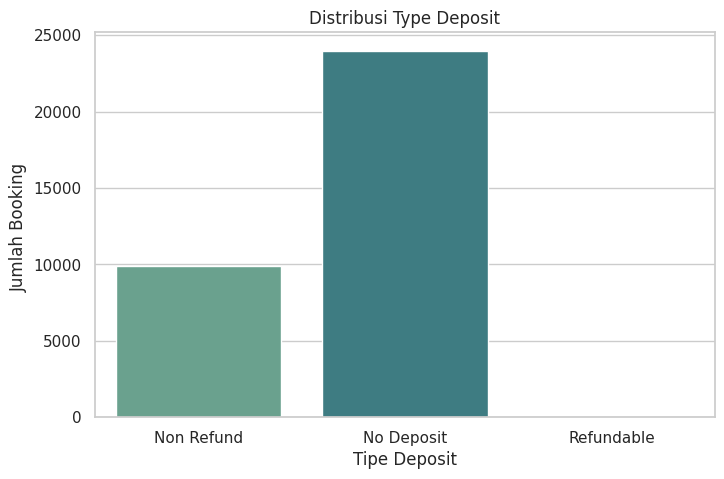

In [ ]:
# Distribusi Type Of deposit
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='deposit_type', palette='crest')
plt.title('Distribusi Type Deposit')
plt.xlabel('Tipe Deposit')
plt.ylabel('Jumlah Booking ')
plt.show()

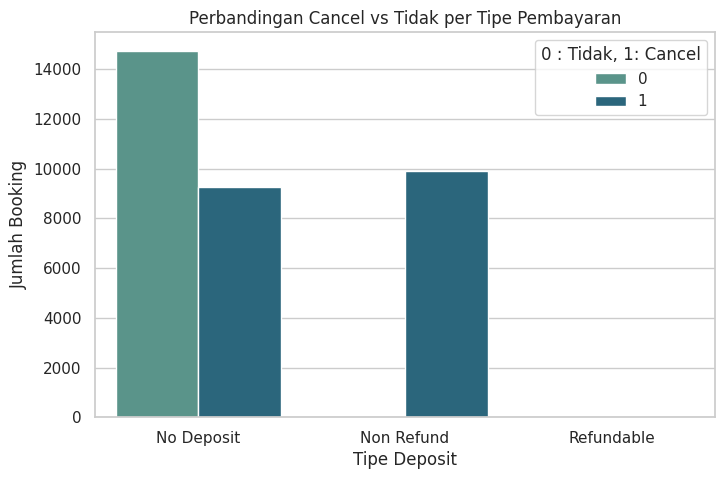

In [ ]:
deposit_cancel_counts = df_clean.groupby(['deposit_type', 'is_canceled']).size().reset_index(name='count')

plt.figure(figsize=(8,5))
sns.barplot(
    x='deposit_type',
    y='count',
    hue='is_canceled',
    data=deposit_cancel_counts,
    palette='crest'
)

plt.title('Perbandingan Cancel vs Tidak per Tipe Pembayaran')
plt.xlabel('Tipe Deposit')
plt.ylabel('Jumlah Booking')
plt.legend(title='0 : Tidak, 1: Cancel')
plt.show()

Insight :
* Tipe pembayaran “No Deposit” memiliki jumlah pembatalan tertinggi sekitar 9.000 pembatalan dari total 14.000 booking.
* Tipe “Non Refund” juga menunjukkan tingkat pembatalan yang cukup tinggi dibandingkan tipe lainnya.

Asumsi :
* No Deposit: Mudah dibatalkan karena pelanggan tidak membayar di awal.
* Non Refund: Pembatalan tetap tinggi kemungkinan karena alasan darurat atau pelanggan tidak memahami kebijakan.

### Type Of Segment


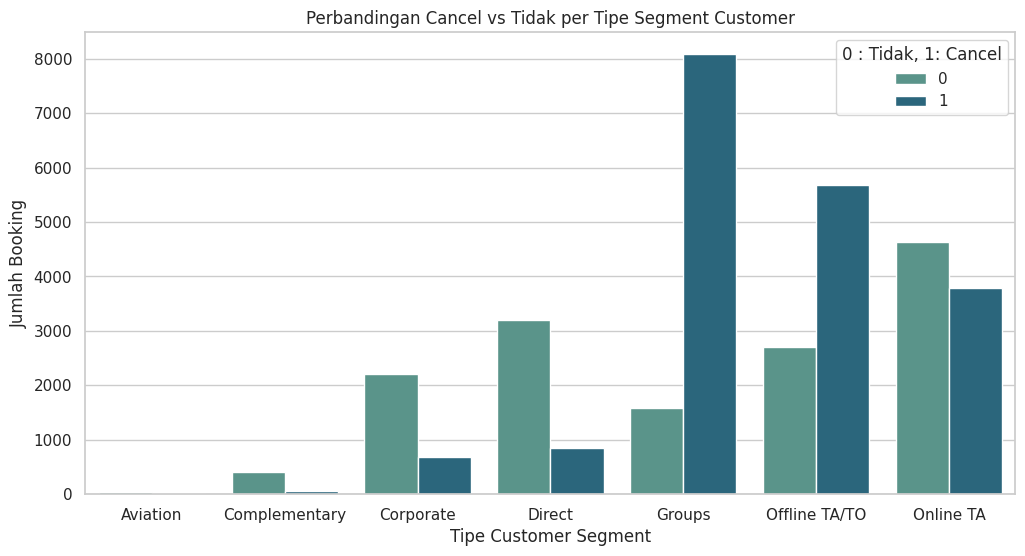

In [ ]:
deposit_cancel_counts = df_clean.groupby(['market_segment', 'is_canceled']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(
    x='market_segment',
    y='count',
    hue='is_canceled',
    data=deposit_cancel_counts,
    palette='crest'
)

plt.title('Perbandingan Cancel vs Tidak per Tipe Segment Customer')
plt.xlabel('Tipe Customer Segment')
plt.ylabel('Jumlah Booking')
plt.legend(title='0 : Tidak, 1: Cancel')
plt.show()


Insight :

* Segmen Groups memiliki tingkat pembatalan tertinggi yaitu sekitar 9.600 booking, lebih dari 8.000 di antaranya dibatalkan, menunjukkan bahwa pemesanan grup cenderung tidak stabil dan bersifat tentatif.
* Segmen Offline TA/TO juga menunjukkan tingkat pembatalan tinggi dari total sekitar 8.300 booking, lebih dari 5.000 dibatalkan. Ini menandakan bahwa agen perjalanan tradisional berisiko tinggi terhadap pembatalan.
* Segmen Online TA memiliki sekitar 3.800 pembatalan dari 8.400 booking. Hal ini mengindikasikan bahwa pelanggan yang memesan secara online lebih mudah membatalkan pesanan karena sistem digital yang lebih fleksibel.

Asumsi :
* Groups: Pembatalan kemungkinan disebabkan oleh perubahan jadwal secara massal atau kendala internal dalam kelompok.
* Offline TA/TO: Kemungkinan karena proses konfirmasi manual yang memakan waktu lebih lama, sehingga meningkatkan potensi pembatalan.
* Online TA: Tingginya pembatalan dapat disebabkan oleh kemudahan sistem pembatalan online dan pelanggan yang menemukan penawaran hotel lain yang lebih murah atau lebih sesuai

# Conclusion & Rekomendation

**Conclusion :**
* Lead time: Semakin panjang jarak waktu antara
pemesanan dan tanggal kedatangan, semakin tinggi kemungkinan pembatalan.

* Special request: Pelanggan yang tidak mengajukan permintaan khusus cenderung lebih sering membatalkan pemesanan.

* Car parking space: Pelanggan yang tidak memerlukan tempat parkir memiliki tingkat pembatalan lebih tinggi dibandingkan yang melakukan permintaan parkir.

* Deposit type: Tipe pembayaran No Deposit dan Non Refund memiliki tingkat pembatalan paling tinggi dibandingkan Refundable.

* Customer segment: Segmen Group dan Offline TA/TO memiliki tingkat pembatalan tertinggi di antara semua segmen pelanggan.
---

---
**Recommendation :**
1. Lead Time
  * Kirim reminder email secara berkala kepada pelanggan yang memesan jauh hari sebelum tanggal kedatangan.
  * Tawarkan harga kompetitif atau diskon early-booking untuk mengurangi kemungkinan pelanggan berpindah ke hotel lain.

2. Special Request
  * Buat paket bundling permintaan khusus (special request) dengan harga menarik agar pelanggan lebih berkomitmen untuk tidak membatalkan pesanan.

3. Car Parking Space
  * Lakukan tracking kebutuhan kendaraan pelanggan sejak awal reservasi untuk memastikan ketersediaan parkir.
  * Berikan penawaran bundling parkir + kamar bagi pelanggan yang membawa kendaraan untuk meningkatkan retensi.

4. Deposit Type
  * Terapkan sistem refundable deposit, agar pelanggan tetap merasa aman namun memiliki tanggung jawab finansial atas pemesanan.
  * Untuk tipe Non-Refund, berikan penawaran eksklusif atau benefit tambahan agar pelanggan merasa menjadi prioritas dan enggan membatalkan.

5. Customer Segment
  * Tingkatkan koordinasi dan komunikasi dengan agen perjalanan (TA/TO) untuk memastikan validitas dan kepastian pemesanan grup.
  * Lakukan follow-up dan reminder langsung ke pelanggan individu untuk memperkuat hubungan dan mengurangi risiko pembatalan.

# Save The Data

In [ ]:
df_clean.to_excel('train_clean.xlsx', index=False)